In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('./secondary_data.csv',delimiter=';')

2. Build a kNN model and evaluate the model using using the metrics discussed in class (Accuracy, TPR, FPR, F1, Kappa, LogLoss and ROC/AUC). Make sure to calculate the prevalence to provide a reference for some of these measures. Make sure to properly clean and prepare the data ahead of building the model.

3. In consideration of all the metrics you just used are there a few that seem more important given the question you are asking?

4. Consider where miss-classification errors are occurring, is there a pattern? If so discuss this pattern and why you think this is the case.

5. Based on your exploration in Part 3/4, change the threshold using the function provided (in the in-class example), what differences do you see in the confusion metric? Does it get better at addressing your question or not, why?

6. Use a metric we did not discuss in class (reference the sklearn model metrics documentation). Once you have the output, summarize in a sentence or two what the metric is and what it means in the context of your question.

7. Summarize your findings speaking through your question, what does the evaluation outputs mean when answering the question? Also, make recommendations on improvements.

In [41]:
print(df)

      class  cap-diameter cap-shape cap-surface cap-color  \
0         p         15.26         x           g         o   
1         p         16.60         x           g         o   
2         p         14.07         x           g         o   
3         p         14.17         f           h         e   
4         p         14.64         x           h         o   
...     ...           ...       ...         ...       ...   
61064     p          1.18         s           s         y   
61065     p          1.27         f           s         y   
61066     p          1.27         s           s         y   
61067     p          1.24         f           s         y   
61068     p          1.17         s           s         y   

      does-bruise-or-bleed gill-attachment gill-spacing gill-color  \
0                        f               e          NaN          w   
1                        f               e          NaN          w   
2                        f               e          NaN  

# How does the cap diameter effect the mushroom being poisonous or edible?

## Clean the data

In [42]:
missing_columns = df.columns[df.isna().any()]
df = df.drop(missing_columns, axis=1)

In [43]:
target = df['class']
feature = df['cap-diameter']

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-color             61069 non-null  object 
 4   does-bruise-or-bleed  61069 non-null  object 
 5   gill-color            61069 non-null  object 
 6   stem-height           61069 non-null  float64
 7   stem-width            61069 non-null  float64
 8   stem-color            61069 non-null  object 
 9   has-ring              61069 non-null  object 
 10  habitat               61069 non-null  object 
 11  season                61069 non-null  object 
dtypes: float64(3), object(9)
memory usage: 5.6+ MB


## Convert object data into category

In [45]:
df = df.astype({col: 'category' for col in df.select_dtypes(include='object').columns})

### Numerical data

In [46]:
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler()
numeric_cols = df.select_dtypes(include='float64').columns
d = scaler.fit_transform(df[numeric_cols])
scaled_df = pd.DataFrame(d, columns=numeric_cols)
df[numeric_cols] = scaled_df

### Categorical data

In [47]:
cat_cols = df.select_dtypes(include='category').columns
encoded = pd.get_dummies(df[cat_cols], drop_first=True)
df = df.drop(cat_cols, axis=1)
df = df.join(encoded)
df.dropna(axis = 0, how = 'any', inplace = True)

In [48]:
print(df['class_p'].value_counts()[1] / df['class_p'].count())

0.44508670520231214


/tmp/ipykernel_1046/3169326131.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['class_p'].value_counts()[1] / df['class_p'].count())


In [66]:
X = df.drop('class_p', axis=1)
y = df['class_p']

## Build the kNN model now

In [49]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.4, stratify=df['class_p'], random_state=114514)
test, val = train_test_split(test, test_size=0.4, stratify=test['class_p'], random_state=114514)

In [50]:
import random
from sklearn.neighbors import KNeighborsClassifier
random.seed(99)  

X_train = train.drop(['class_p'], axis=1).values
y_train = train['class_p'].values

neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [51]:
X_test = test.drop(['class_p'], axis=1).values
y_test = test['class_p'].values

print(neigh.score(X_test, y_test))

0.9954284934497817


In [52]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df,  test_size=0.4, stratify = df['class_p'], random_state=99)
test, val = train_test_split(test, test_size=0.4, stratify=test['class_p'], random_state=99) 

import random
from sklearn.neighbors import KNeighborsClassifier
random.seed(11)  

X_train = train.drop(['class_p'], axis=1)
y_train = train['class_p'].values

neigh = KNeighborsClassifier(n_neighbors=9)
neigh.fit(X_train, y_train)

# Measure accuracy on the training data
X_train = train.drop(['class_p'], axis=1)
y_train = train['class_p'].values

train_accuracy = neigh.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy}")

Training Accuracy: 0.9918124505335553


In [53]:
X_val = val.drop(['class_p'], axis=1)
y_val = val['class_p'].values

print(neigh.score(X_val, y_val))

0.9896643471142038


In [54]:
X_test = test.drop(['class_p'], axis=1).values
y_test = test['class_p'].values

In [55]:
y_val_pred = neigh.predict(X_val)

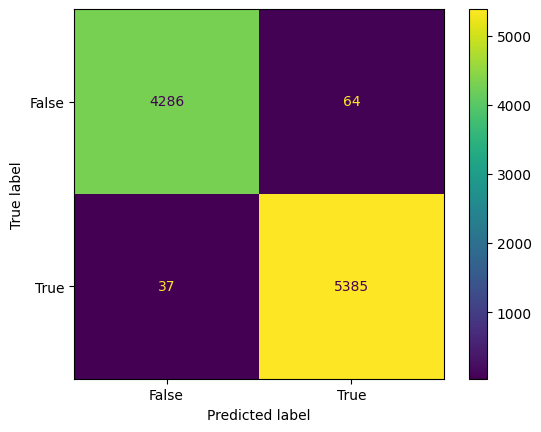

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

cm = confusion_matrix(y_val,y_val_pred, labels=neigh.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=neigh.classes_)  
disp.plot()
plt.show()

In [57]:
# Predict probabilities
y_val_pred_proba = neigh.predict_proba(X_val)[:, 1]  # Extract probability of class 1

# Compute Log Loss
from sklearn.metrics import log_loss

logloss = log_loss(y_val, y_val_pred_proba)
print("Log Loss:", logloss)

# Compute ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_val_pred_proba)
print("ROC-AUC Score:", roc_auc)

Log Loss: 0.03853284501676834
ROC-AUC Score: 0.99919917577176


In [58]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, cohen_kappa_score,
    log_loss, roc_auc_score
)

# Extract values from confusion matrix
TN, FP, FN, TP = cm.ravel()

# Compute metrics
accuracy = accuracy_score(y_val, y_val_pred)
tpr = recall_score(y_val, y_val_pred)  # Same as Sensitivity/Recall
fpr = FP / (FP + TN)
f1 = f1_score(y_val, y_val_pred)
kappa = cohen_kappa_score(y_val, y_val_pred)
logloss = log_loss(y_val, y_val_pred_proba)  # Probabilities required
roc_auc = roc_auc_score(y_val, y_val_pred_proba)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"True Positive Rate (TPR / Recall): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Cohen’s Kappa: {kappa:.4f}")
print(f"Log Loss: {logloss:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")


Accuracy: 0.9897
True Positive Rate (TPR / Recall): 0.9932
False Positive Rate (FPR): 0.0147
F1-score: 0.9907
Cohen’s Kappa: 0.9791
Log Loss: 0.0385
ROC-AUC Score: 0.9992


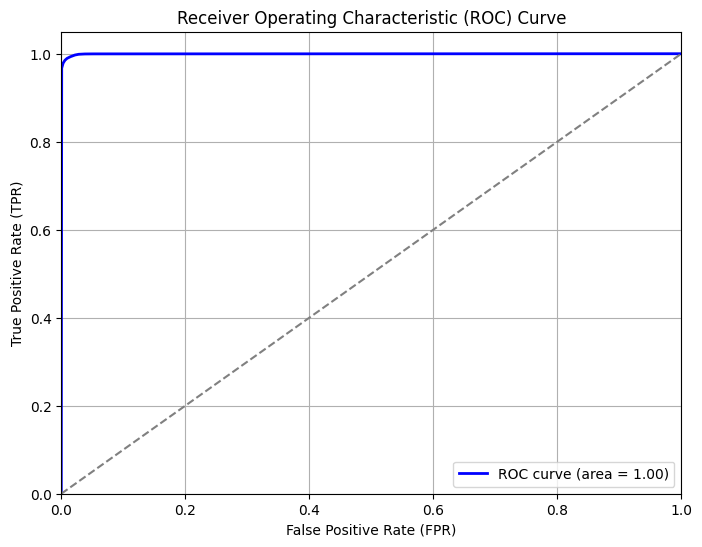

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Predict probability scores for the positive class (class 1)
y_val_pred_proba = neigh.predict_proba(X_val)[:, 1]  

# Compute FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal reference line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

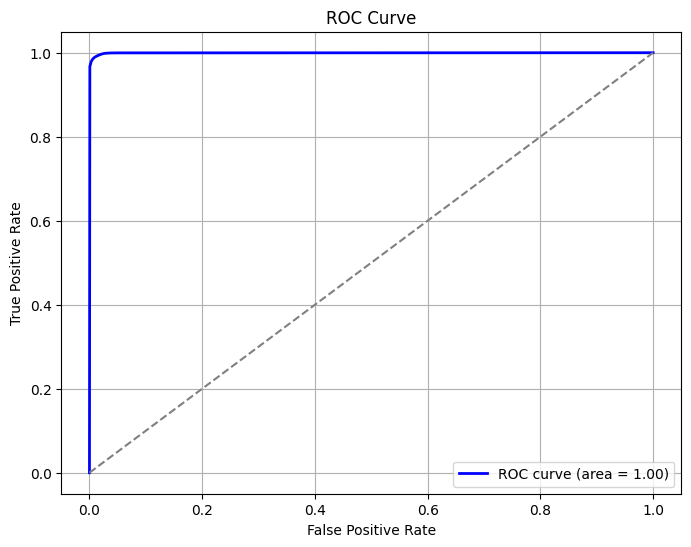

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# Retrain model
neigh.fit(X_train, y_train)

# Get probabilities
y_val_pred_proba = neigh.predict_proba(X_val)[:, 1]

# Compute ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Random classifier reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [63]:
from sklearn import metrics
metrics.RocCurveDisplay.from_predictions(final_model.target, final_model.pos_prob)
#Set labels and midline...
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

NameError: name 'final_model' is not defined

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify = y, random_state=21)

In [69]:
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50, stratify = y_test,random_state=49)

In [70]:
mush_3NN = KNeighborsClassifier(n_neighbors=10)
#Now let's fit our knn model to the training data
mush_3NN.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [71]:
mush_3NN.score(X_tune, y_tune)

0.9877729257641922

In [72]:
mush_prob1 = mush_3NN.predict_proba(X_tune) #This function gives percent probability for both class (0,1)
mush_prob1[:5]

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.]])

In [73]:
#Now let's retrieve the predictions, based on the tuning set...
mush_pred1 = mush_3NN.predict(X_tune)
mush_pred1[:5] #looks good, notice how the probabilities above correlate with the predictions below

array([ True, False,  True, False,  True])

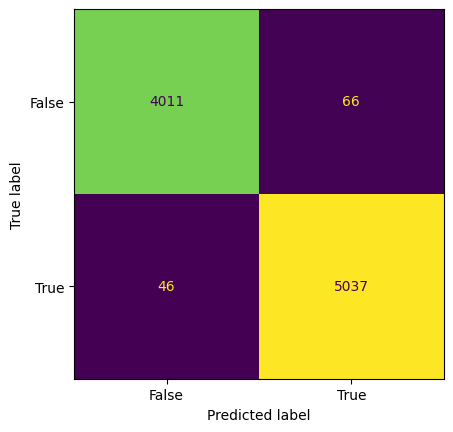

In [76]:
final_model= pd.DataFrame({'neg_prob':mush_prob1[:, 0], 'pred':mush_pred1,'target':y_tune, 'pos_prob':mush_prob1[:, 1]})
metrics.confusion_matrix(final_model.target,final_model.pred) #looks good, but simplistic...
metrics.ConfusionMatrixDisplay.from_predictions(final_model.target,final_model.pred, display_labels = [False, True], colorbar=False)

In [77]:
#What if we want to adjust the threshold to produce a new set of evaluation metrics
#Let's build a function so we can make the threshold whatever we want, not just the default 50%
def adjust_thres(x,y,z):
  #x=pred_probablities, y=threshold, z=test_outcome
  thres = (np.where(x > y, 1,0))
  #np.where is essentially a condensed if else statement. The first argument is the condition, then the true output, then the false output
  return metrics.ConfusionMatrixDisplay.from_predictions(z,thres, display_labels = [False, True], colorbar=False)

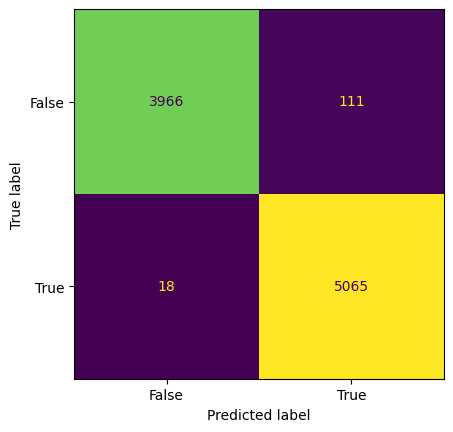

In [78]:
# Give it a try with a threshold of .35
adjust_thres(final_model.pos_prob,.35,final_model.target)
#What's the difference? Try different percents now, what happens?

Text(0.5, 0, 'False Positive Rate')

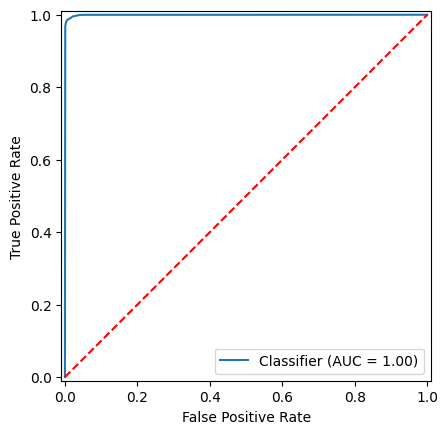

In [79]:
#Now let's use our model to obtain an ROC Curve and the AUC
metrics.RocCurveDisplay.from_predictions(final_model.target, final_model.pos_prob)
#Set labels and midline...
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

In [ ]:
df